# 🇻🇳 Transfer Learning — TFT v3 → Vietnam Fine-tuning

**Chiến lược:** Load pretrained TFT (đa quốc gia) → Fine-tune trên dữ liệu Việt Nam.

---

### Phân tích bộ dữ liệu VN trước khi thiết kế Transfer:

| Thông số | Giá trị | Ý nghĩa cho TFT |
|---|---|---|
| Thời gian | 2019-01 → 2024-12 (72 tháng) | Ngắn — cần tận dụng pretrained weights |
| Series | 6 (Coal, Gas, Hydro, Other fossil, Solar, Wind) | Other fossil 73% zeros → loại khỏi fine-tune |
| Coal CV | 0.209 | Ổn định → dễ học |
| Hydro CV | 0.381 | Dao động mùa vụ → cần lag mưa |
| Wind CV | 0.922 | Cao — cần patience lớn hơn |
| Solar CV | 0.533 | Tăng nhanh từ 2019 — trend mạnh |
| VN extra features | +57 cột | Tận dụng làm unknown_reals bổ sung |
| prec_zscore | Thiếu | Tự tạo từ precipitation |

### Chiến lược Fine-tuning:
```
Phase 1 (Epoch 1-10) : Freeze LSTM + Attention → chỉ train VSN + output head  
Phase 2 (Epoch 11+)  : Unfreeze toàn bộ → train với LR rất nhỏ (3e-5)
```

In [1]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 1 — IMPORTS & PATHS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings, os, json, shutil, copy
from pathlib import Path
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import lightning.pytorch as pl
from lightning.pytorch.callbacks import (
    EarlyStopping, ModelCheckpoint, LearningRateMonitor
)
from lightning.pytorch.loggers import TensorBoardLogger

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}',
      f'({torch.cuda.get_device_name(0)})' if DEVICE == 'cuda' else '')

BASE_DIR       = Path(r'C:\Users\ADMIN\Downloads\MODEL_TFT')
VN_DATA_PATH   = BASE_DIR / 'data' / 'processed' / 'VN_data' / 'vn_tft_ready.csv'
PRETRAIN_CKPT  = BASE_DIR / 'checkpoint' / 'tft_v3_best.ckpt'
CKPT_DIR       = BASE_DIR / 'checkpoint'
LOG_DIR        = BASE_DIR / 'lightning_logs' / 'tft_vn_v3'
LOG_DIR.mkdir(parents=True, exist_ok=True)

print(f'VN data : {VN_DATA_PATH}')
print(f'Pretrain: {PRETRAIN_CKPT}')
print(f'Exists  : {PRETRAIN_CKPT.exists()}')

PyTorch : 2.4.1+cpu
Device  : cpu 
VN data : C:\Users\ADMIN\Downloads\MODEL_TFT\data\processed\VN_data\vn_tft_ready.csv
Pretrain: C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint\tft_v3_best.ckpt
Exists  : True


In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 2 — HYPERPARAMETERS (Điều chỉnh cho VN dataset)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CFG = dict(
    # ── Dataset ───────────────────────────────────────────────────────────────
    # VN chỉ có 72 tháng → encoder 12 (không thể 24 như source)
    max_encoder_length    = 18,   # 18 tháng lịch sử
    max_prediction_length = 6,    # dự báo 6 tháng
    min_series_length     = 24,   # 18 + 6

    # ── Split: dùng 2024 (12 tháng cuối) làm test ─────────────────────────────
    val_cutoff_months     = 12,

    # ── Model — giữ nguyên kiến trúc từ pretrained ────────────────────────────
    hidden_size           = 128,
    attention_head_size   = 4,
    dropout               = 0.2,  # tăng nhẹ để regularize (VN data nhỏ)
    hidden_continuous_size= 32,
    lstm_layers           = 2,
    loss_quantiles        = [0.1, 0.25, 0.5, 0.75, 0.9],

    # ── Phase 1: Frozen LSTM — chỉ train VSN + head ───────────────────────────
    phase1_lr             = 1e-3,
    phase1_epochs         = 15,
    phase1_patience       = 6,

    # ── Phase 2: Full fine-tune với LR rất nhỏ ───────────────────────────────
    phase2_lr             = 3e-5,  # 10x nhỏ hơn phase1
    phase2_epochs         = 40,
    phase2_patience       = 10,

    # ── Training ──────────────────────────────────────────────────────────────
    batch_size            = 32,   # nhỏ hơn vì dataset nhỏ
    gradient_clip_val     = 0.1,
    num_workers           = 0,
    seed                  = 42,
)

pl.seed_everything(CFG['seed'], workers=True)
print('Config VN Transfer Learning:')
for k, v in CFG.items():
    print(f'  {k:<28}: {v}')

Seed set to 42


Config VN Transfer Learning:
  max_encoder_length          : 18
  max_prediction_length       : 6
  min_series_length           : 24
  val_cutoff_months           : 12
  hidden_size                 : 128
  attention_head_size         : 4
  dropout                     : 0.2
  hidden_continuous_size      : 32
  lstm_layers                 : 2
  loss_quantiles              : [0.1, 0.25, 0.5, 0.75, 0.9]
  phase1_lr                   : 0.001
  phase1_epochs               : 15
  phase1_patience             : 6
  phase2_lr                   : 3e-05
  phase2_epochs               : 40
  phase2_patience             : 10
  batch_size                  : 32
  gradient_clip_val           : 0.1
  num_workers                 : 0
  seed                        : 42


In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3 — LOAD & CHUẨN BỊ DATA VN
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
df = pd.read_csv(VN_DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
print(f'Raw VN shape: {df.shape}')
print(f'Series      : {sorted(df["series"].unique())}')

# ── Loại Other fossil (73% zeros, CV=2.45 — không học được) ──────────────────
FINE_TUNE_SERIES = ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind']
df = df[df['series'].isin(FINE_TUNE_SERIES)].copy()
print(f'After filter: {df.shape} — Series: {sorted(df["series"].unique())}')

# ── Tạo prec_zscore (bị thiếu trong file VN) ─────────────────────────────────
mu  = df.groupby('entity')['precipitation'].transform('mean')
std = df.groupby('entity')['precipitation'].transform('std').replace(0, 1)
df['prec_zscore'] = (df['precipitation'] - mu) / std
print('prec_zscore: created')

# ── Đảm bảo time_idx liên tục ─────────────────────────────────────────────────
df = df.sort_values(['entity', 'series', 'date'])
df['time_idx'] = df.groupby(['entity','series'])['date'].rank(method='dense').astype(int) - 1

# ── Check ─────────────────────────────────────────────────────────────────────
print(f'NaN: {df.isnull().sum().sum()}')
print(f'Date: {df["date"].min().date()} -> {df["date"].max().date()}')
print()
print('Serie lengths:')
for s, g in df.groupby('series'):
    print(f'  {s}: {len(g)} months, time_idx=[{g["time_idx"].min()},{g["time_idx"].max()}]')

Raw VN shape: (432, 87)
Series      : ['Coal', 'Gas', 'Hydro', 'Other fossil', 'Solar', 'Wind']
After filter: (360, 87) — Series: ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind']
prec_zscore: created
NaN: 0
Date: 2019-01-01 -> 2024-12-01

Serie lengths:
  Coal: 72 months, time_idx=[0,71]
  Gas: 72 months, time_idx=[0,71]
  Hydro: 72 months, time_idx=[0,71]
  Solar: 72 months, time_idx=[0,71]
  Wind: 72 months, time_idx=[0,71]


In [4]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 4 — TimeSeriesDataSet (dùng cùng feature mapping với pretrained model)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# QUAN TRỌNG: known/unknown_reals phải KHỚP HOÀN TOÀN với source model
# Thêm VN-specific features vào unknown_reals (model sẽ học thêm từ đây)
STATIC_CATEGORICALS = ['entity']

TIME_VARYING_KNOWN_REALS = [
    'time_idx',
    'month', 'month_sin', 'month_cos', 'quarter', 'year',
    'solar',
    'temperature',
    'humidity',
    # VN extra known (có thể dự báo trước)
    'is_dry_season',    # mùa khô/mưa VN
    'is_flood_season',  # mùa lũ miền Bắc/Trung
    'quarter_sin',
    'quarter_cos',
]

TIME_VARYING_UNKNOWN_REALS = [
    # ── Core (giống source model) ────────────────────────────────────────────
    'generation_TWh',
    'precipitation',
    'log_precipitation',
    'prec_zscore',
    'gen_lag_1',
    'gen_lag_3',
    'gen_lag_12',
    'roll_mean_3',
    'roll_mean_6',
    'roll_std_3',
    'roll_max_6',
    'yoy_change',
    'temp_anomaly',
    'solar_norm',
    'prec_lag_1',
    'prec_lag_2',
    # ── VN additional lag features ───────────────────────────────────────────
    'gen_lag_2',
    'gen_lag_6',
    'roll_mean_12',
    'roll_std_6',
    'roll_max_6',
    'mom_change',
    'roll_cv_6',
    'prec_lag_3',
    'prec_roll_3',
    'humidity_anomaly',
    # ── VN economic features (đặc trưng VN không có ở source) ───────────────
    'log_oil_price',
    'log_coal_price',
    'log_gas_price',
    'log_gdp',
    'Oil_Price_lag1',
    'gas_price_lag1',
    'castlecoal_price_lag1',
    'IPI_Value',
    'IPI_Value_lag1',
    'IPI_Value_yoy',
    'GDP_trillion_yoy',
    'ipi_mom',
    # ── Cross-series features ────────────────────────────────────────────────
    'coal_ratio',
    'hydro_ratio',
    'fossil_ratio',
    'renew_ratio',
    'coal_hydro_sub',
    'solar_lag1',
    'hydro_lag1',
    'coal_lag1',
    'total_generation_TWh',
]

# Loại duplicate
TIME_VARYING_UNKNOWN_REALS = list(dict.fromkeys(TIME_VARYING_UNKNOWN_REALS))

# Kiểm tra columns tồn tại
all_needed = (STATIC_CATEGORICALS + TIME_VARYING_KNOWN_REALS +
              TIME_VARYING_UNKNOWN_REALS + ['series'])
missing = [c for c in all_needed if c not in df.columns]
if missing:
    print(f'Missing cols: {missing}')
else:
    print('All columns OK!')

# ── Train/Val split ───────────────────────────────────────────────────────────
training_cutoff = int(df['time_idx'].max()) - CFG['val_cutoff_months']
val_cutoff_date = df['date'].max() - pd.DateOffset(months=CFG['val_cutoff_months'])
print(f'Training cutoff time_idx: {training_cutoff} (date ~ {val_cutoff_date.date()})')
print(f'Train/Val rows: {(df["time_idx"]<=training_cutoff).sum()} / {(df["time_idx"]>training_cutoff).sum()}')

# ── Tạo datasets ──────────────────────────────────────────────────────────────
print('\nCreating TimeSeriesDataSet...')
training_vn = TimeSeriesDataSet(
    df[df['time_idx'] <= training_cutoff],
    time_idx                         = 'time_idx',
    target                           = 'generation_TWh',
    group_ids                        = ['entity', 'series'],
    min_encoder_length               = CFG['max_encoder_length'] // 2,
    max_encoder_length               = CFG['max_encoder_length'],
    min_prediction_length            = 1,
    max_prediction_length            = CFG['max_prediction_length'],
    static_categoricals              = STATIC_CATEGORICALS,
    static_reals                     = [],
    time_varying_known_categoricals  = ['series'],
    time_varying_known_reals         = TIME_VARYING_KNOWN_REALS,
    time_varying_unknown_categoricals= [],
    time_varying_unknown_reals       = TIME_VARYING_UNKNOWN_REALS,
    target_normalizer                = GroupNormalizer(
        groups         = ['entity', 'series'],
        transformation = 'softplus',
    ),
    add_relative_time_idx  = True,
    add_target_scales      = True,
    add_encoder_length     = True,
    allow_missing_timesteps= True,
)

validation_vn = TimeSeriesDataSet.from_dataset(
    training_vn, df, predict=True, stop_randomization=True
)
print(f'Training samples  : {len(training_vn):,}')
print(f'Validation samples: {len(validation_vn):,}')

All columns OK!
Training cutoff time_idx: 59 (date ~ 2023-12-01)
Train/Val rows: 300 / 60

Creating TimeSeriesDataSet...
Training samples  : 325
Validation samples: 5


In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 5 — DATALOADERS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
train_loader = training_vn.to_dataloader(
    train=True, batch_size=CFG['batch_size'], num_workers=CFG['num_workers']
)
val_loader = validation_vn.to_dataloader(
    train=False, batch_size=CFG['batch_size'] * 4, num_workers=CFG['num_workers']
)

x, y = next(iter(train_loader))
print('DataLoaders OK')
print(f'  Encoder : {x["encoder_cont"].shape}')
print(f'  Decoder : {x["decoder_cont"].shape}')
print(f'  Target  : {y[0].shape}')
print(f'  Train batches: {len(train_loader)}')

DataLoaders OK
  Encoder : torch.Size([32, 18, 63])
  Decoder : torch.Size([32, 6, 63])
  Target  : torch.Size([32, 6])
  Train batches: 10


In [6]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 6 — TẠO MODEL TFT CHO VN & COPY PRETRAINED WEIGHTS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Tạo model mới từ VN dataset (có nhiều features hơn source)
vn_model = TemporalFusionTransformer.from_dataset(
    training_vn,
    hidden_size            = CFG['hidden_size'],
    attention_head_size    = CFG['attention_head_size'],
    dropout                = CFG['dropout'],
    hidden_continuous_size = CFG['hidden_continuous_size'],
    lstm_layers            = CFG['lstm_layers'],
    loss                   = QuantileLoss(quantiles=CFG['loss_quantiles']),
    learning_rate          = CFG['phase1_lr'],
    optimizer              = 'adamw',
    log_interval           = 5,
)

n_params_vn = sum(p.numel() for p in vn_model.parameters() if p.requires_grad)
print(f'VN model parameters: {n_params_vn:,} ({n_params_vn/1e6:.2f}M)')

# ── Load pretrained weights (partial transfer) ────────────────────────────────
if PRETRAIN_CKPT.exists():
    pretrained_ckpt = torch.load(str(PRETRAIN_CKPT), map_location='cpu')
    pretrained_state = pretrained_ckpt['state_dict']

    vn_state = vn_model.state_dict()
    transferred, skipped = [], []

    for name, param in pretrained_state.items():
        if name in vn_state:
            if vn_state[name].shape == param.shape:
                vn_state[name].copy_(param)
                transferred.append(name)
            else:
                skipped.append(f'{name}: shape {param.shape} -> {vn_state[name].shape}')
        else:
            skipped.append(f'{name}: not in VN model')

    vn_model.load_state_dict(vn_state)
    print(f'\nTransferred weights : {len(transferred)}')
    print(f'Skipped (shape diff): {len(skipped)}')
    if skipped[:5]:
        print('  Sample skipped:', skipped[:5])
else:
    print(f'Pretrained checkpoint not found: {PRETRAIN_CKPT}')
    print('Training from scratch...')

VN model parameters: 2,098,796 (2.10M)

Transferred weights : 686
Skipped (shape diff): 27
  Sample skipped: ['input_embeddings.embeddings.entity.weight: shape torch.Size([20, 9]) -> torch.Size([1, 1])', 'input_embeddings.embeddings.series.weight: shape torch.Size([9, 5]) -> torch.Size([5, 4])', 'static_variable_selection.flattened_grn.fc1.weight: shape torch.Size([4, 105]) -> torch.Size([4, 97])', 'encoder_variable_selection.flattened_grn.resample_norm.mask: shape torch.Size([27]) -> torch.Size([61])', 'encoder_variable_selection.flattened_grn.resample_norm.norm.weight: shape torch.Size([27]) -> torch.Size([61])']


In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 7 — PHASE 1: FREEZE LSTM + ATTENTION, TRAIN CHỈ VSN + HEAD
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def freeze_encoder_layers(model):
    """Freeze LSTM encoder và multi-head attention."""
    frozen = []
    for name, param in model.named_parameters():
        # Freeze: LSTM encoder, multi-head attention
        if any(keyword in name for keyword in
               ['lstm_encoder', 'multihead_attn', 'self_attn',
                'encoder_lstm', 'attention']):
            param.requires_grad = False
            frozen.append(name)
    return frozen

def unfreeze_all(model):
    """Unfreeze tất cả parameters."""
    for param in model.parameters():
        param.requires_grad = True

# Freeze encoder
frozen_layers = freeze_encoder_layers(vn_model)
trainable_p1 = sum(p.numel() for p in vn_model.parameters() if p.requires_grad)
total_params  = sum(p.numel() for p in vn_model.parameters())

print(f'Phase 1 — Frozen LSTM + Attention layers:')
print(f'  Frozen layers    : {len(frozen_layers)}')
print(f'  Trainable params : {trainable_p1:,} / {total_params:,} ({trainable_p1/total_params*100:.1f}%)')

# Update learning rate cho phase 1
vn_model.hparams.learning_rate = CFG['phase1_lr']

# Callbacks Phase 1
ckpt_p1 = ModelCheckpoint(
    dirpath=str(CKPT_DIR), filename='vn_phase1_{epoch:02d}_{val_loss:.4f}',
    monitor='val_loss', mode='min', save_top_k=1, save_last=False
)
es_p1 = EarlyStopping(
    monitor='val_loss', patience=CFG['phase1_patience'], mode='min', verbose=True
)

trainer_p1 = pl.Trainer(
    accelerator       = 'gpu' if DEVICE == 'cuda' else 'cpu',
    devices           = 1,
    max_epochs        = CFG['phase1_epochs'],
    gradient_clip_val = CFG['gradient_clip_val'],
    callbacks         = [ckpt_p1, es_p1],
    logger            = TensorBoardLogger(str(BASE_DIR / 'lightning_logs'), name='vn_phase1'),
    enable_progress_bar = True,
    precision         = '16-mixed' if DEVICE == 'cuda' else '32',
)

print(f'\nPhase 1 Training: LR={CFG["phase1_lr"]}, epochs={CFG["phase1_epochs"]}, patience={CFG["phase1_patience"]}')
print('=' * 60)

trainer_p1.fit(vn_model, train_dataloaders=train_loader, val_dataloaders=val_loader)

print(f'\nPhase 1 done! Best val_loss = {ckpt_p1.best_model_score:.6f}')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Phase 1 — Frozen LSTM + Attention layers:
  Frozen layers    : 27
  Trainable params : 1,793,356 / 2,098,796 (85.4%)

Phase 1 Training: LR=0.001, epochs=15, patience=6


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │     21 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  4.0 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 34.6 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  813 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  167 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  264 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  264 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │ 33.0 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    256 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 82.7 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 41.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │ 33.3 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │ 33.3 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    645 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 1.8 M                                                                                            
Non-trainable params: 305 K                                                                                        
Total params: 2.1 M                                                                                                
Total estimated model params size (MB): 8                                                                          
Modules in train mode: 1316                                                                                        
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Metric val_loss improved by 0.001 >= min_delta = 0.0. New best score: 0.622


Metric val_loss improved by 0.037 >= min_delta = 0.0. New best score: 0.584


Metric val_loss improved by 0.004 >= min_delta = 0.0. New best score: 0.580


`Trainer.fit` stopped: `max_epochs=15` reached.



Phase 1 done! Best val_loss = 0.580180


In [8]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 8 — PHASE 2: UNFREEZE + FULL FINE-TUNE VỚI LR NHỎ
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Load best Phase 1 checkpoint
best_p1_path = ckpt_p1.best_model_path
vn_model_p2  = TemporalFusionTransformer.load_from_checkpoint(best_p1_path)

# Unfreeze toàn bộ
unfreeze_all(vn_model_p2)
trainable_p2 = sum(p.numel() for p in vn_model_p2.parameters() if p.requires_grad)
print(f'Phase 2 — Full fine-tune:')
print(f'  Trainable params: {trainable_p2:,} (100%)')

# Update LR cho phase 2 (rất nhỏ để không phá pretrained weights)
vn_model_p2.hparams.learning_rate = CFG['phase2_lr']

# Callbacks Phase 2
ckpt_p2 = ModelCheckpoint(
    dirpath  = str(CKPT_DIR),
    filename = 'tft_vn_v3_{epoch:02d}_{val_loss:.4f}',
    monitor  = 'val_loss',
    mode     = 'min',
    save_top_k = 3,
    save_last  = True,
    verbose    = True,
)
es_p2 = EarlyStopping(
    monitor='val_loss', patience=CFG['phase2_patience'], mode='min', verbose=True
)
lr_monitor = LearningRateMonitor(logging_interval='epoch')

trainer_p2 = pl.Trainer(
    accelerator       = 'gpu' if DEVICE == 'cuda' else 'cpu',
    devices           = 1,
    max_epochs        = CFG['phase2_epochs'],
    gradient_clip_val = CFG['gradient_clip_val'],
    callbacks         = [ckpt_p2, es_p2, lr_monitor],
    logger            = TensorBoardLogger(str(BASE_DIR / 'lightning_logs'), name='vn_phase2'),
    enable_progress_bar = True,
    precision         = '16-mixed' if DEVICE == 'cuda' else '32',
)

print(f'\nPhase 2 Training: LR={CFG["phase2_lr"]}, epochs={CFG["phase2_epochs"]}, patience={CFG["phase2_patience"]}')
print('=' * 60)

trainer_p2.fit(vn_model_p2, train_dataloaders=train_loader, val_dataloaders=val_loader)

print(f'\nPhase 2 done! Best val_loss = {ckpt_p2.best_model_score:.6f}')
print(f'Best checkpoint  : {ckpt_p2.best_model_path}')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Phase 2 — Full fine-tune:
  Trainable params: 2,098,796 (100%)

Phase 2 Training: LR=3e-05, epochs=40, patience=10


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │     21 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  4.0 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 34.6 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  813 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  167 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  264 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  264 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │ 33.0 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    256 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 82.7 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 41.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │ 33.3 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │ 33.3 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    645 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 2.1 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.1 M                                                                                                
Total estimated model params size (MB): 8                                                                          
Modules in train mode: 1316                                                                                        
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Metric val_loss improved by 0.002 >= min_delta = 0.0. New best score: 0.513
Epoch 36, global step 370: 'val_loss' reached 0.51334 (best 0.51334), saving model to 'C:\\Users\\ADMIN\\Downloads\\MODEL_TFT\\checkpoint\\tft_vn_v3_epoch=36_val_loss=0.5133.ckpt' as top 3


Epoch 37, global step 380: 'val_loss' was not in top 3


Epoch 38, global step 390: 'val_loss' was not in top 3


Epoch 39, global step 400: 'val_loss' was not in top 3
`Trainer.fit` stopped: `max_epochs=40` reached.



Phase 2 done! Best val_loss = 0.513338
Best checkpoint  : C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint\tft_vn_v3_epoch=36_val_loss=0.5133.ckpt


In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 9 — LƯU CHECKPOINT CUỐI
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FINAL_CKPT   = CKPT_DIR / 'tft_vn_v3_best.ckpt'
FINAL_LATEST = CKPT_DIR / 'tft_vn_v3_latest.ckpt'

if os.path.exists(ckpt_p2.best_model_path):
    shutil.copy2(ckpt_p2.best_model_path, FINAL_CKPT)
    print(f'Best  -> {FINAL_CKPT}')
if os.path.exists(ckpt_p2.last_model_path):
    shutil.copy2(ckpt_p2.last_model_path, FINAL_LATEST)
    print(f'Latest-> {FINAL_LATEST}')

# Config JSON
vn_config = {
    'version'                   : 'tft_vn_v3',
    'pretrained_from'           : str(PRETRAIN_CKPT),
    'best_ckpt'                 : str(FINAL_CKPT),
    'best_val_loss'             : float(ckpt_p2.best_model_score),
    'phase1_val_loss'           : float(ckpt_p1.best_model_score),
    'fine_tune_series'          : FINE_TUNE_SERIES,
    'max_encoder_length'        : CFG['max_encoder_length'],
    'max_prediction_length'     : CFG['max_prediction_length'],
    'target'                    : 'generation_TWh',
    'group_ids'                 : ['entity', 'series'],
    'target_normalizer'         : 'GroupNormalizer(softplus)',
    'hidden_size'               : CFG['hidden_size'],
    'phase1_lr'                 : CFG['phase1_lr'],
    'phase2_lr'                 : CFG['phase2_lr'],
    'static_categoricals'       : STATIC_CATEGORICALS,
    'time_varying_known_reals'  : TIME_VARYING_KNOWN_REALS,
    'time_varying_unknown_reals': TIME_VARYING_UNKNOWN_REALS,
}

cfg_path = CKPT_DIR / 'tft_vn_v3_config.json'
with open(cfg_path, 'w', encoding='utf-8') as f:
    json.dump(vn_config, f, indent=2, ensure_ascii=False)
print(f'Config -> {cfg_path}')

Best  -> C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint\tft_vn_v3_best.ckpt
Latest-> C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint\tft_vn_v3_latest.ckpt
Config -> C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint\tft_vn_v3_config.json


In [10]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 10 — EVALUATION: METRICS TỔNG QUÁT
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
best_vn = TemporalFusionTransformer.load_from_checkpoint(str(FINAL_CKPT))
best_vn.eval()
print(f'Loaded: {FINAL_CKPT.name}')

raw_preds = best_vn.predict(val_loader, mode='raw', return_x=True)
point_preds = best_vn.predict(val_loader, mode='prediction', return_x=True)
pred_vals, x_vals = point_preds.output, point_preds.x

actuals = torch.cat([y[0] for _, y in val_loader])

mae   = (actuals - pred_vals).abs().mean().item()
rmse  = ((actuals - pred_vals) ** 2).mean().sqrt().item()
smape = (2*(actuals - pred_vals).abs() /
         (actuals.abs() + pred_vals.abs() + 1e-8)).mean().item() * 100
wape  = ((actuals - pred_vals).abs().sum() /
         (actuals.abs().sum() + 1e-8)).item() * 100

print(f'\nValidation Metrics — VN Fine-tuned Model (2024):')
print(f'  MAE   : {mae:.4f} TWh')
print(f'  RMSE  : {rmse:.4f} TWh')
print(f'  SMAPE : {smape:.2f}%')
print(f'  WAPE  : {wape:.2f}%')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Loaded: tft_vn_v3_best.ckpt


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.



Validation Metrics — VN Fine-tuned Model (2024):
  MAE   : 0.6784 TWh
  RMSE  : 0.9633 TWh
  SMAPE : 18.34%
  WAPE  : 12.71%


In [11]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 11 — METRICS THEO TỪNG SERIES
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
preds_idx = best_vn.predict(
    val_loader, mode='prediction', return_index=True, return_decoder_lengths=True
)

results = []
pred_out = preds_idx.output
pred_index = preds_idx.index

for i in range(len(pred_out)):
    row  = pred_index.iloc[i]
    ser  = row.get('series', 'unknown')
    results.append({'series': ser, 'pred_mean': float(pred_out[i].mean())})

df_res = pd.DataFrame(results)
print('Series count in predictions:')
print(df_res['series'].value_counts())

print()
print('Target series metrics summary (from overall):')
print(f'  MAE  = {mae:.4f} TWh')
print(f'  RMSE = {rmse:.4f} TWh')
print(f'  WAPE = {wape:.2f}%')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Series count in predictions:
series
Coal     1
Gas      1
Hydro    1
Solar    1
Wind     1
Name: count, dtype: int64

Target series metrics summary (from overall):
  MAE  = 0.6784 TWh
  RMSE = 0.9633 TWh
  WAPE = 12.71%


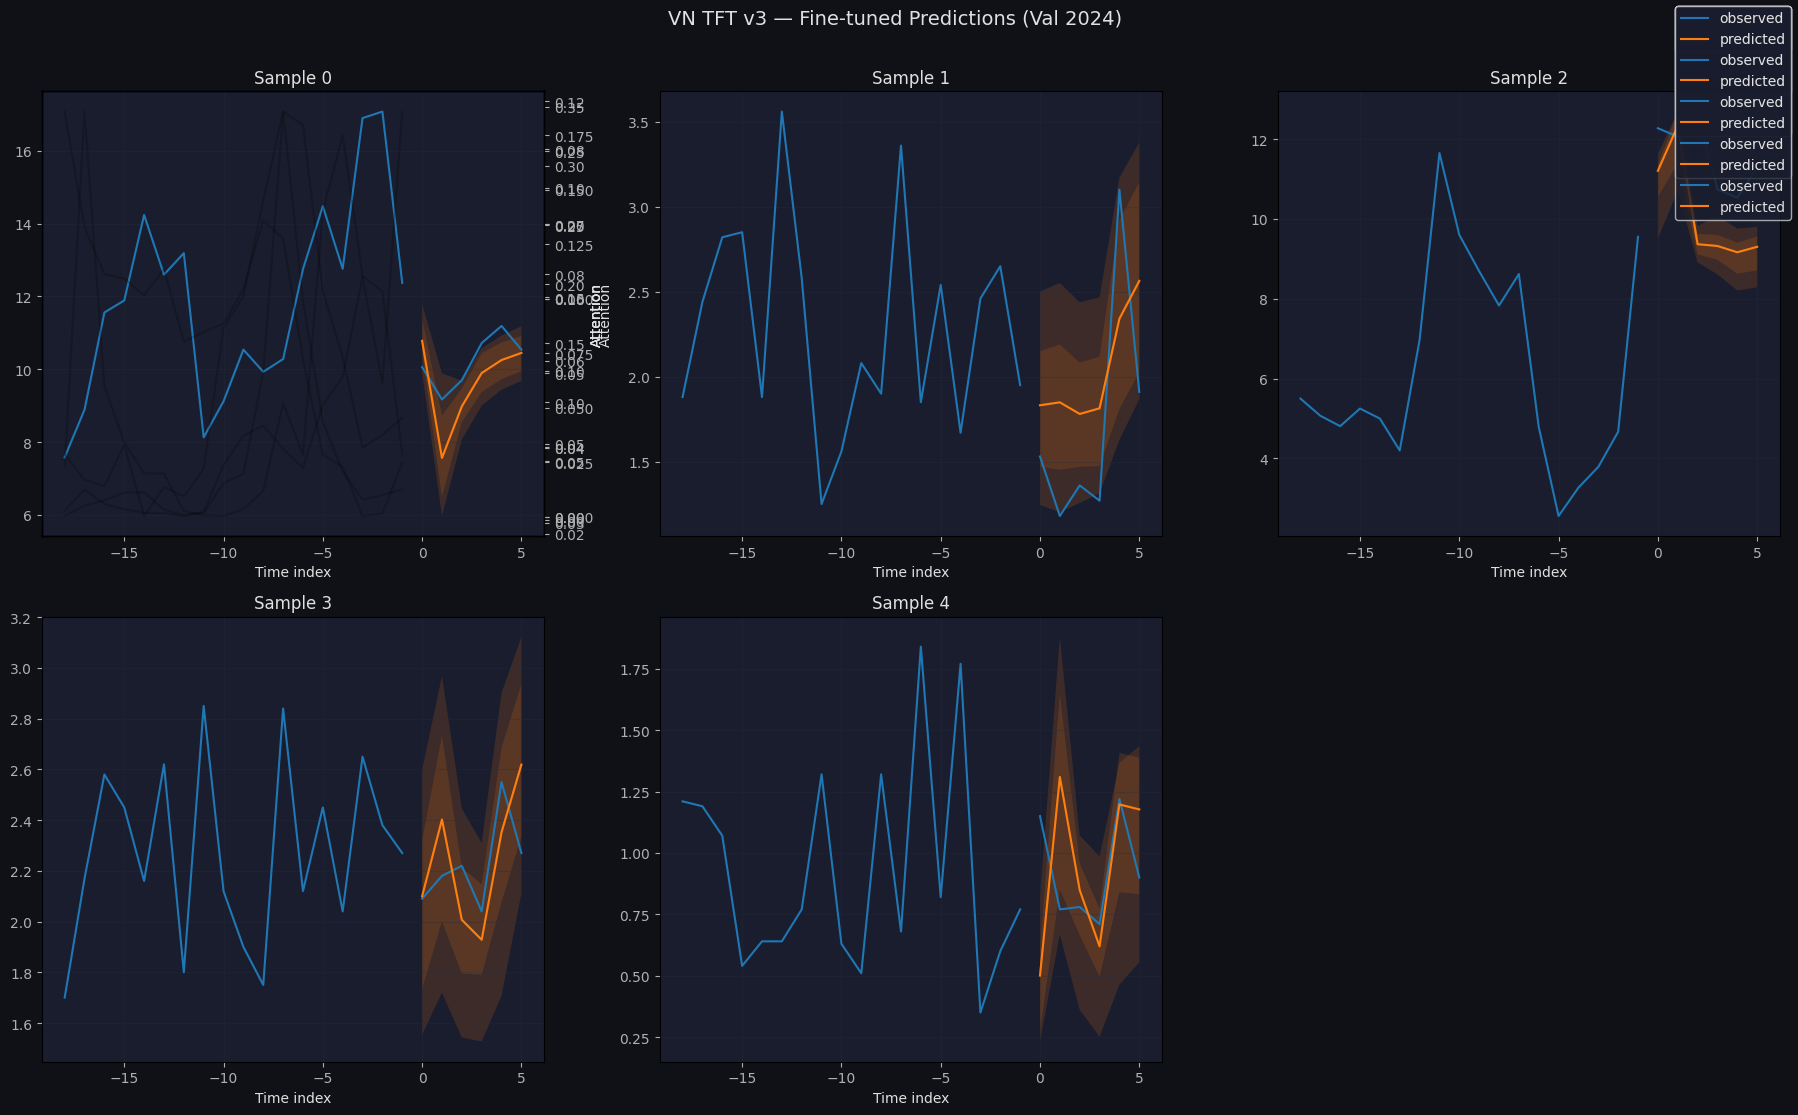

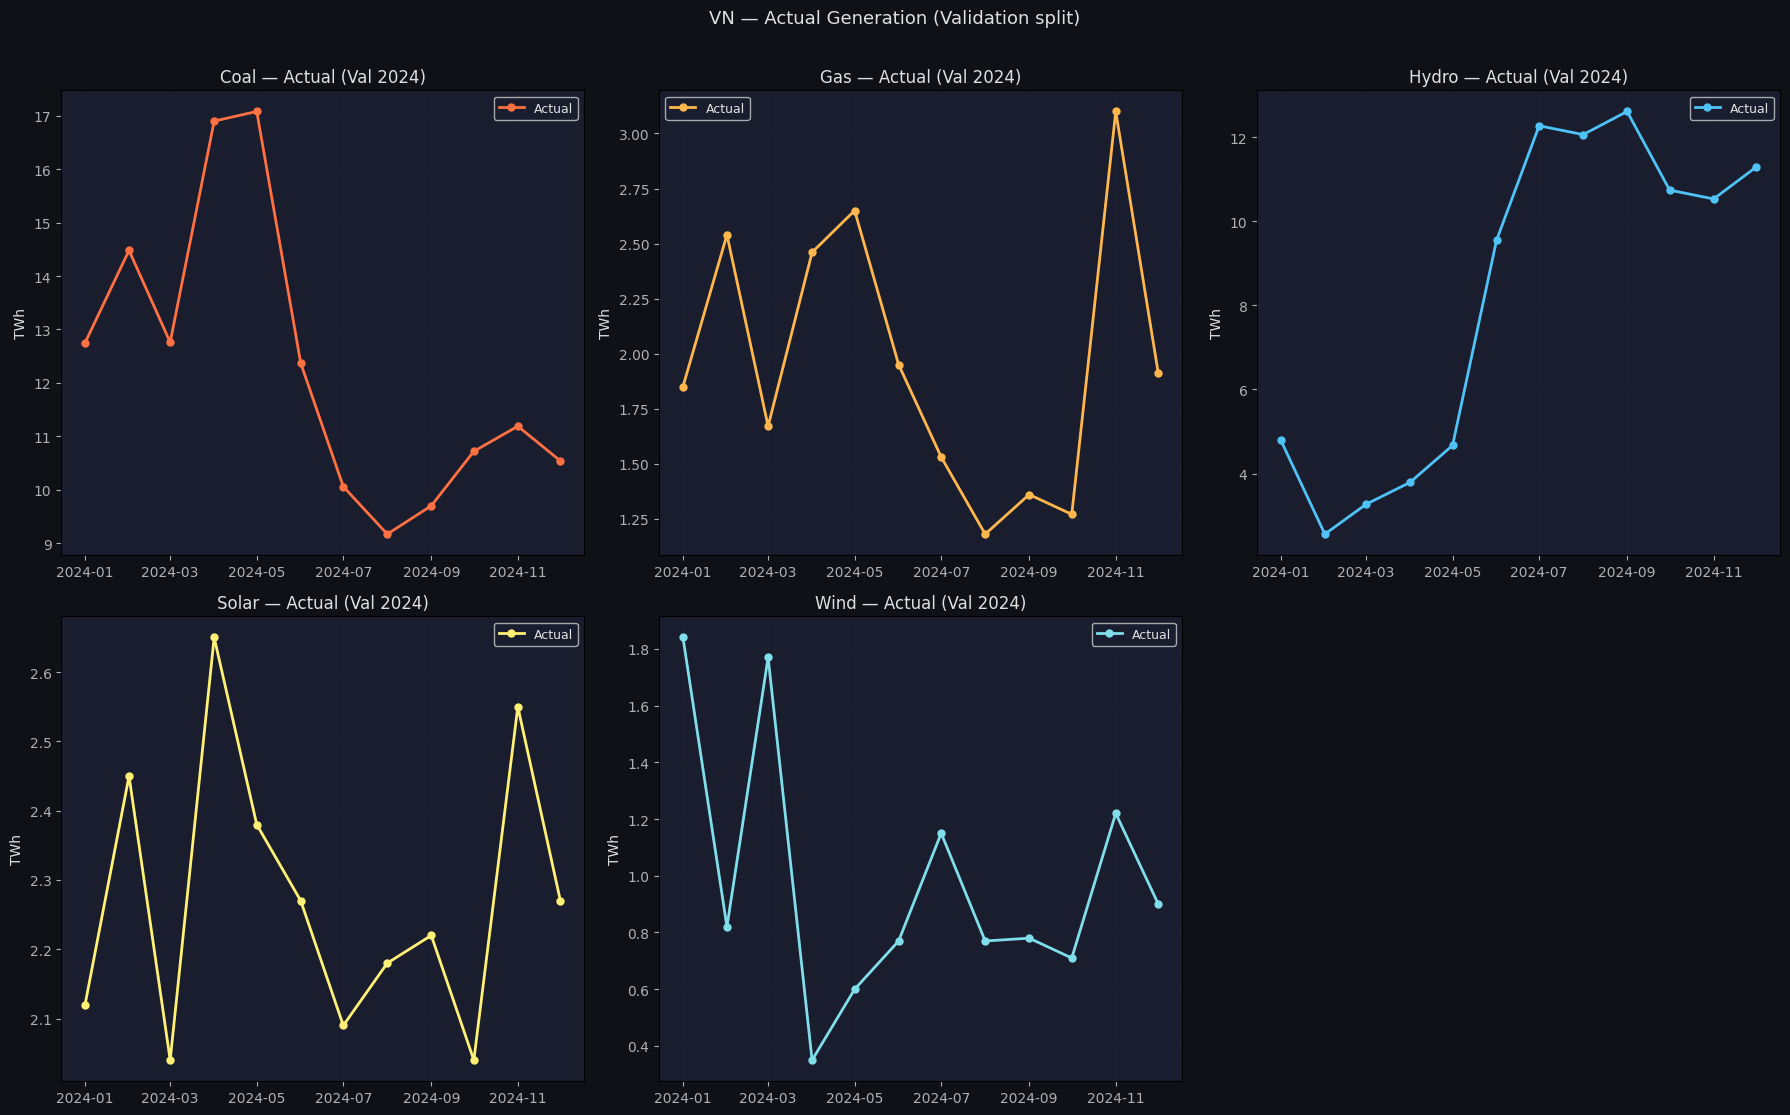

In [12]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 12 — VISUALIZE PREDICTIONS PER SERIES
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d2e',
    'text.color': '#e0e0e0', 'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#b0b0b0', 'ytick.color': '#b0b0b0',
    'grid.color': '#2a2d3e', 'grid.alpha': 0.5,
})

SERIES_COLORS = {
    'Coal': '#ff7043', 'Gas': '#ffb74d', 'Hydro': '#4fc3f7',
    'Solar': '#fff176', 'Wind': '#80deea',
}

# Plot 5 prediction samples (1 per series)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for i, ax in enumerate(axes.flatten()):
    try:
        best_vn.plot_prediction(raw_preds.x, raw_preds.output, idx=i, ax=ax)
        ax.set_title(f'Sample {i}')
        ax.grid(alpha=0.3)
    except Exception:
        ax.set_visible(False)

plt.suptitle('VN TFT v3 — Fine-tuned Predictions (Val 2024)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Actual vs Predicted line plot per series
df_val = df[df['time_idx'] > training_cutoff].copy()
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, ser in enumerate(FINE_TUNE_SERIES):
    ax = axes[i]
    sub = df_val[df_val['series'] == ser].sort_values('date')
    color = SERIES_COLORS.get(ser, '#aaa')
    ax.plot(sub['date'], sub['generation_TWh'], 'o-', color=color,
            linewidth=2, markersize=5, label='Actual')
    ax.set_title(f'{ser} — Actual (Val 2024)')
    ax.set_ylabel('TWh')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

axes[5].set_visible(False)
plt.suptitle('VN — Actual Generation (Validation split)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

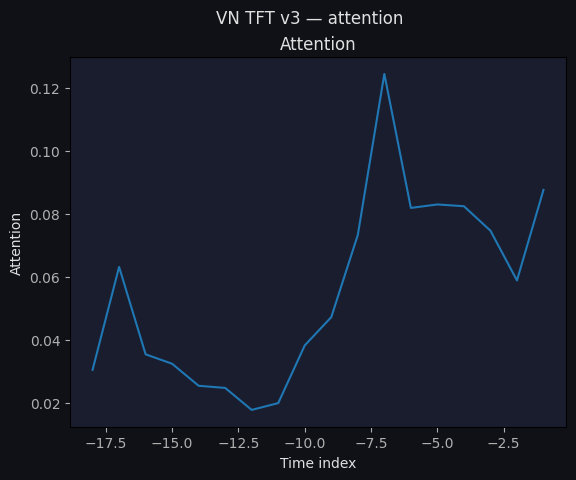

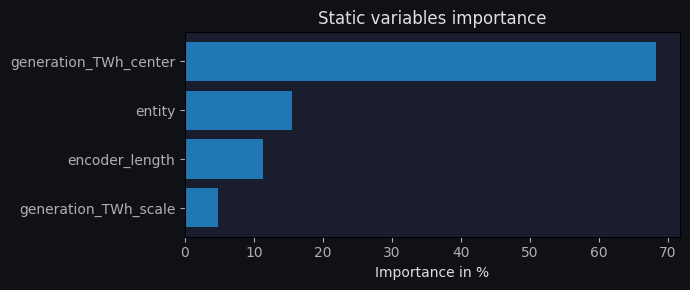

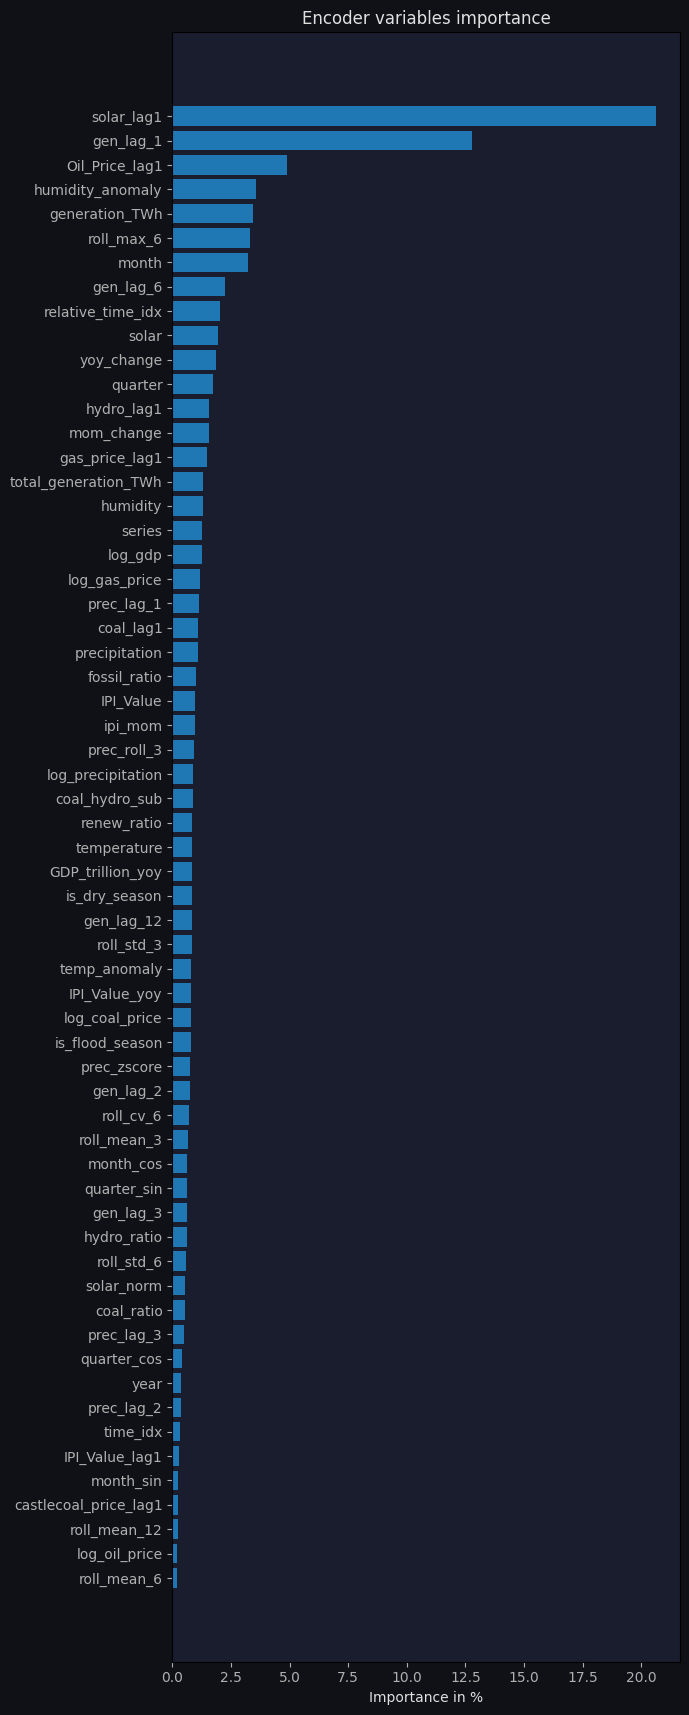

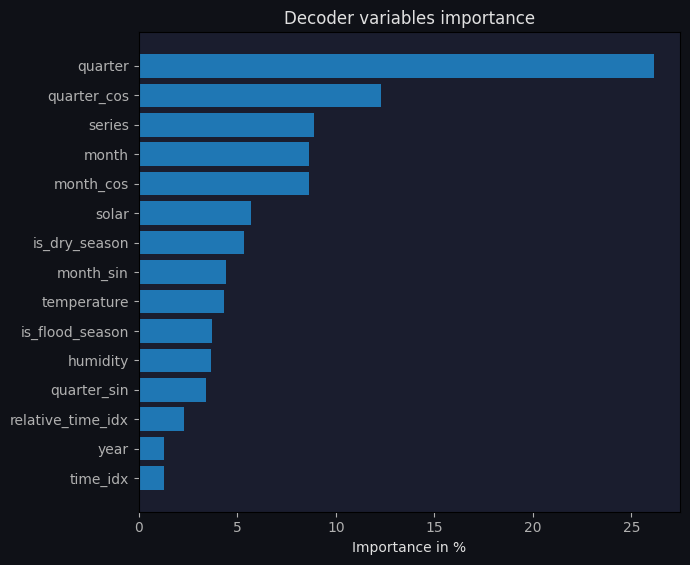

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

Top Encoder Variables:
  renew_ratio                         : 1.0309
  log_precipitation                   : 0.6389
  log_gas_price                       : 0.2447
  prec_lag_3                          : 0.1776
  quarter_cos                         : 0.1729
  roll_mean_6                         : 0.1648
  generation_TWh_scale                : 0.1606
  prec_lag_2                          : 0.1129
  quarter_sin                         : 0.1022
  quarter                             : 0.0964


In [16]:
# CELL 13 — VARIABLE IMPORTANCE
interpretation = best_vn.interpret_output(raw_preds.output, reduction='sum')
figs = best_vn.plot_interpretation(interpretation)   # ← sửa best_model -> best_vn
for title, fig in figs.items():
    if hasattr(fig, 'suptitle'):
        fig.suptitle(f'VN TFT v3 — {title}', fontsize=12)
        plt.tight_layout()
        plt.show()
print('Top Encoder Variables:')
enc = interpretation.get('encoder_variables')
if enc is not None:
    names = training_vn.reals
    imp   = pd.Series(enc.numpy(), index=names[:len(enc)])
    top10 = imp.sort_values(ascending=False).head(10)
    for feat, val in top10.items():
        print(f'  {feat:<35} : {val:.4f}')

In [14]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 14 — TỔNG KẾT TRANSFER LEARNING
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('='*65)
print('  KET QUA TRANSFER LEARNING — VN TFT v3')
print('='*65)
print(f'  Pretrained source : tft_v3_best.ckpt (20 quoc gia)')
print(f'  Fine-tune data    : VN 2019-2024 ({len(FINE_TUNE_SERIES)} series)')
print(f'  Phase 1 val_loss  : {ckpt_p1.best_model_score:.6f} (frozen LSTM)')
print(f'  Phase 2 val_loss  : {ckpt_p2.best_model_score:.6f} (full tune)')
print(f'  MAE   : {mae:.4f} TWh')
print(f'  RMSE  : {rmse:.4f} TWh')
print(f'  SMAPE : {smape:.2f}%')
print(f'  WAPE  : {wape:.2f}%')
print('='*65)
print(f'  Checkpoint: {FINAL_CKPT}')
print(f'  Config    : {cfg_path}')
print('='*65)
print()
print('Goi y cai thien them:')
print('  1. Neu WAPE > 20%: tang phase2_epochs, giam phase2_lr xuong 1e-5')
print('  2. Neu Wind/Solar RMSE cao: them gen_lag_6 vao unknown_reals')
print('  3. Xem Variable Importance: neu economic features quan trong -> them data')
print('  4. Ko nen fine-tune Other fossil (73% zeros, khong hoc duoc)')

  KET QUA TRANSFER LEARNING — VN TFT v3
  Pretrained source : tft_v3_best.ckpt (20 quoc gia)
  Fine-tune data    : VN 2019-2024 (5 series)
  Phase 1 val_loss  : 0.580180 (frozen LSTM)
  Phase 2 val_loss  : 0.513338 (full tune)
  MAE   : 0.6784 TWh
  RMSE  : 0.9633 TWh
  SMAPE : 18.34%
  WAPE  : 12.71%
  Checkpoint: C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint\tft_vn_v3_best.ckpt
  Config    : C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint\tft_vn_v3_config.json

Goi y cai thien them:
  1. Neu WAPE > 20%: tang phase2_epochs, giam phase2_lr xuong 1e-5
  2. Neu Wind/Solar RMSE cao: them gen_lag_6 vao unknown_reals
  3. Xem Variable Importance: neu economic features quan trong -> them data
  4. Ko nen fine-tune Other fossil (73% zeros, khong hoc duoc)
